In [33]:
!pip -q install trl 

In [34]:
# Uninstall the libraries to ensure a clean state
!pip uninstall -qy torch torchvision torchaudio transformers peft

# Clear the pip cache to avoid reinstalling a broken cached version
!pip cache purge

# Reinstall the libraries. This will fetch the latest stable and compatible versions.
!pip install -q  torchvision torchaudio torch "torchao>0.16.0"
!pip install -q "transformers<6.0.0,>=4.41.0"
!pip install -q transformers peft accelerate datasets

Files removed: 30
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 5.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 62.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 53.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 1.3 MB/s eta 0:00:0000:0100:01m


In [35]:
import torch
import os
import shutil
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from trl import DPOConfig, DPOTrainer

In [36]:
# --- 1. CONFIGURATION ---
MODEL_ID = "Qwen/Qwen3-1.7B-Base"
SFT_ADAPTERS = "/kaggle/input/models/chris36/weights-sft-v2/pytorch/default/1"
DPO_TRAIN_DATA = "/kaggle/input/datasets/chris36/dpo-train-dataset/Mpaga_Christophe_1_Dataset_Train_DPO_052026.jsonl"
DPO_TEST_DATA = "/kaggle/input/datasets/chris36/dpo-dataset-test/Mpaga_Christophe_1_Dataset_Test_DPO_052026.jsonl"
OUTPUT_DIR = "/kaggle/working/chsa_qwen3_dpo_final"
ZIP_NAME = "Mpaga_Christophe_1_Model_DPO_052026"

In [37]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [38]:
# --- 2. CHARGEMENT MODÈLE (FP16 STABLE P100) ---
print("📥 Chargement du modèle SFT...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=torch.float16, device_map="auto", trust_remote_code=True
)

# Chargement des adaptateurs SFT comme base
model = PeftModel.from_pretrained(model, SFT_ADAPTERS, is_trainable=True)
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False

📥 Chargement du modèle SFT...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [39]:
# --- 3. DATASETS ---
train_ds = load_dataset("json", data_files=DPO_TRAIN_DATA, split="train")
test_ds = load_dataset("json", data_files=DPO_TEST_DATA, split="train")

In [47]:
# --- 4. CONFIG DPO ULTRA-LÉGÈRE ---
dpo_config = DPOConfig(
    output_dir=OUTPUT_DIR,
    beta=0.2,
    num_train_epochs=0.5,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,  # On augmente l'accumulation pour compenser le petit batch
    learning_rate=5e-7,
    # --- RÉGLAGES ANTI-CRASH ---
    max_length=512,  # On réduit de 1024 à 512 (suffisant pour le triage)
    # max_prompt_length=256,     # On réduit de 512 à 256
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    fp16=True,
    eval_strategy="steps",
    eval_steps=20,  # On évalue moins souvent pour sauver la VRAM
    per_device_eval_batch_size=1,
    logging_steps=1,
    save_strategy="no",
    report_to="none",
)

In [48]:
# --- 5. NETTOYAGE MÉMOIRE AVANT LANCEMENT ---
import gc

model.config.use_cache = False  # Obligatoire avec gradient checkpointing
gc.collect()
torch.cuda.empty_cache()

# --- 6. INITIALISATION DU TRAINER ---
trainer = DPOTrainer(
    model=model,
    ref_model=None,  # TRL utilisera le modèle avec adaptateurs désactivés (économie VRAM)
    args=dpo_config,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
)

print("⚡ Lancement de l'alignement DPO (Mode économie d'énergie)...")
trainer.train()

⚡ Lancement de l'alignement DPO (Mode économie d'énergie)...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
20,0.689673,0.683512,1.319712,215977.000000,5.373595,5.695592,0.637131,-0.077110,-0.099123,0.433333,0.022013,-224.859572,-233.913353
38,0.696232,0.680104,1.319888,402534.000000,5.367871,5.690706,0.636954,-0.084728,-0.114971,0.453333,0.030243,-224.897660,-233.992594


TrainOutput(global_step=38, training_loss=0.6816617407296833, metrics={'train_runtime': 983.095, 'train_samples_per_second': 0.61, 'train_steps_per_second': 0.039, 'total_flos': 3834949275955200.0, 'train_loss': 0.6816617407296833, 'epoch': 0.5066666666666667})

📊 Génération des graphiques de performance...


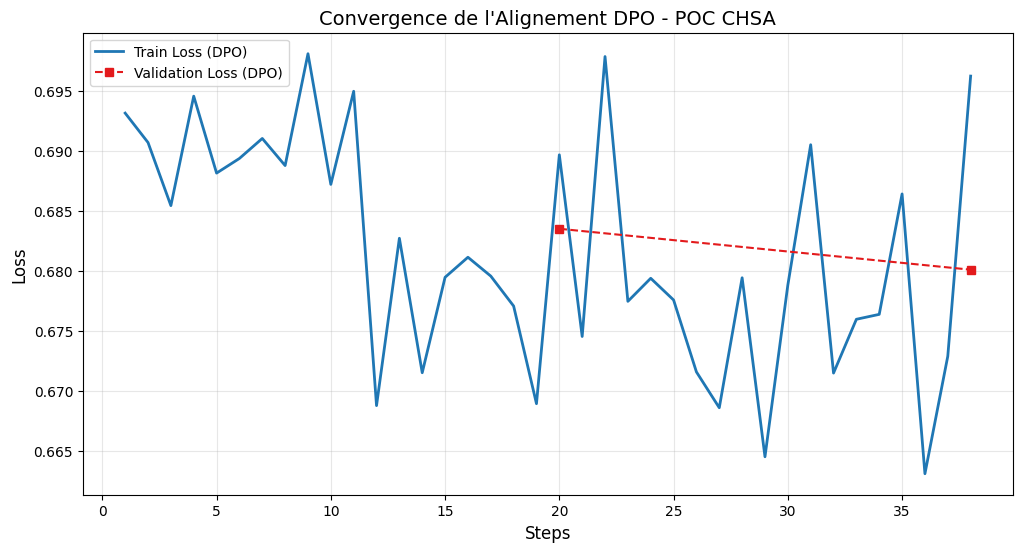

In [49]:
# --- 7. GÉNÉRATION DES COURBES TRAIN/VAL LOSS ---
print("📊 Génération des graphiques de performance...")
history = trainer.state.log_history

train_loss = [x["loss"] for x in history if "loss" in x]
train_steps = [x["step"] for x in history if "loss" in x]
val_loss = [x["eval_loss"] for x in history if "eval_loss" in x]
val_steps = [x["step"] for x in history if "eval_loss" in x]

plt.figure(figsize=(12, 6))
plt.plot(
    train_steps, train_loss, label="Train Loss (DPO)", color="#1f77b4", linewidth=2
)
if val_loss:
    plt.plot(
        val_steps,
        val_loss,
        label="Validation Loss (DPO)",
        color="#e31a1c",
        marker="s",
        linestyle="--",
    )

plt.title("Convergence de l'Alignement DPO - POC CHSA", fontsize=14)
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("dpo_convergence_Mpaga.png", dpi=300)
plt.show()

In [50]:
# --- 8. SAUVEGARDE ET ARCHIVAGE ZIP ---
print("💾 Sauvegarde et création du ZIP final...")
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Création du ZIP pour téléchargement
shutil.make_archive(ZIP_NAME, "zip", OUTPUT_DIR)

print("\n✅ OPÉRATION TERMINÉE !")
print(f"Modèle sauvé dans : {OUTPUT_DIR}")
print(
    f"Archive prête : {ZIP_NAME}.zip ({os.path.getsize(ZIP_NAME + '.zip') / 1e6:.2f} MB)"
)
print("Graphique sauvé : dpo_convergence_Mpaga.png")

💾 Sauvegarde et création du ZIP final...

✅ OPÉRATION TERMINÉE !
Modèle sauvé dans : /kaggle/working/chsa_qwen3_dpo_final
Archive prête : Mpaga_Christophe_1_Model_DPO_052026.zip (131.22 MB)
Graphique sauvé : dpo_convergence_Mpaga.png


In [51]:
import pandas as pd

# Extraire l'historique du trainer
history_data = trainer.state.log_history

# Transformer en DataFrame Pandas
df_logs = pd.DataFrame(history_data)

# Sauvegarder en CSV pour votre rapport
df_logs.to_csv("Mpaga_Christophe_Logs_DPO_052026.csv", index=False)

print("✅ Fichier CSV créé ! Téléchargez-le dans le panneau 'Output'.")
display(df_logs.tail(10))  # Affiche les dernières lignes

✅ Fichier CSV créé ! Téléchargez-le dans le panneau 'Output'.


,loss,grad_norm,learning_rate,entropy,num_tokens,logits/chosen,logits/rejected,mean_token_accuracy,rewards/chosen,rewards/rejected,...,eval_rewards/rejected,eval_rewards/accuracies,eval_rewards/margins,eval_logps/chosen,eval_logps/rejected,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
31,0.690513,20.737434,1.052632e-07,1.351056,326984.0,6.127517,5.563027,0.661376,-0.115146,-0.126068,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,0.671492,15.021665,9.210526e-08,1.373380,338151.0,6.535710,5.865949,0.664431,-0.063787,-0.108710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,0.675973,14.751642,7.894737e-08,1.097388,349118.0,5.908839,5.532437,0.600772,-0.066619,-0.102283,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,0.676383,26.010443,6.578947e-08,1.384755,360012.0,6.579509,5.844290,0.651015,-0.093691,-0.129313,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,0.686414,17.305096,5.263158e-08,1.262498,371360.0,5.805580,5.981479,0.686261,-0.093289,-0.108047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,0.663107,15.626414,3.947368e-08,1.367723,381582.0,5.776662,5.657768,0.586119,-0.056509,-0.119447,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,0.672895,14.568671,2.631579e-08,1.295562,392616.0,6.319329,6.639835,0.649030,-0.075918,-0.121446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,0.696232,14.990622,1.315789e-08,1.354110,402534.0,5.080567,5.041416,0.631615,-0.079727,-0.074542,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.114971,0.453333,0.030243,-224.89766,-233.992594,NaN,NaN,NaN,NaN,NaN
40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,983.095,0.61,0.039,3.834949e+15,0.681662
